In [1]:
# Load LeafletSC 
import LeafletSC
import os
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

from LeafletSC.clustering.find_intron_clusters import main as find_intron_clusters
from LeafletSC.clustering.prepare_model_input import main as prep_model_input
from LeafletSC.clustering.find_intron_clusters import visualize_local_events

# Define path that contains junction files
juncs_path = "/gpfs/commons/projects/knowles_singlecell_splicing/CZhang_2018_mouse_dev/male_whole_cortex/Leaflet/"
print("The junctions are loaded from the following path: " + juncs_path) 

# print the files in the path 
print("The files in the path are: " + str(os.listdir(juncs_path)))

# define path for saving the output data 
output_path = "/gpfs/commons/projects/knowles_singlecell_splicing/CZhang_2018_mouse_dev/male_whole_cortex/LeafletAnalysis/"

# we provide a gtf file for the human genome as well to make better sense of the junctions that are detected in cells
# please replace with the path to the gtf file on your system
gtf_file="/gpfs/commons/projects/knowles_singlecell_splicing/CZhang_2018_mouse_dev/reference-genome/gencode.vM34.basic.annotation.gtf" 

# SRA sample info
SRA_samples="/gpfs/commons/projects/knowles_singlecell_splicing/CZhang_2018_mouse_dev/male_whole_cortex/SraRunTable_WholeCortex_Mouse.txt"

The junctions are loaded from the following path: /gpfs/commons/projects/knowles_singlecell_splicing/CZhang_2018_mouse_dev/male_whole_cortex/Leaflet/
The files in the path are: ['SRR1805824_junctions.bed', 'SRR1805819_junctions.bed', 'SRR1805823_barcodes.txt', 'SRR1812034_barcodes.txt', 'SRR1805828_junctions_with_barcodes.bed', 'SRR1805819_barcodes.txt', 'SRR1805814_barcodes.txt', 'SRR1805814_junctions_with_barcodes.bed', 'SRR1805820_barcodes.txt', 'SRR1805815_barcodes.txt', 'SRR1812034_junctions.bed', 'SRR1805821_barcodes.txt', 'SRR1805817_barcodes.txt', 'SRR1805828_junctions.bed', 'SRR1805821_junctions_with_barcodes.bed', 'SRR1805822_junctions_with_barcodes.bed', 'SRR1805816_barcodes.txt', 'SRR1805817_junctions_with_barcodes.bed', 'SRR1805825_barcodes.txt', 'SRR1805816_junctions.bed', 'SRR1812033_junctions_with_barcodes.bed', 'SRR1805827_junctions.bed', 'SRR1805815_junctions_with_barcodes.bed', 'SRR1805826_junctions.bed', 'SRR1805828_barcodes.txt', 'SRR1805827_junctions_with_barcodes

In [2]:
# read in metacells 
cells_pub = pd.read_csv(SRA_samples)
cells_pub.head()

,Run,AGE,Assay Type,AvgSpotLen,Bases,BioProject,BioSample,BioSampleModel,Bytes,Center Name,...,Organism,Platform,ReleaseDate,create_date,version,Sample Name,sex,SRA Study,strain,tissue
0,SRR1805814,E14.5,RNA-Seq,202,10884925944,PRJNA275412,SAMN03344261,Model organism or animal,7350069982,COLUMBIA UNIVERSITY MEDICAL CENTER,...,Mus musculus,ILLUMINA,2015-03-03T00:00:00Z,2015-02-18T13:13:00Z,1,E14a,male,SRP055008,C57BL/6,whole cortex
1,SRR1805815,E14.5,RNA-Seq,202,10991507810,PRJNA275412,SAMN03344262,Model organism or animal,7337865856,COLUMBIA UNIVERSITY MEDICAL CENTER,...,Mus musculus,ILLUMINA,2015-03-03T00:00:00Z,2015-02-18T13:43:00Z,1,E14b,male,SRP055008,C57BL/7,whole cortex
2,SRR1805816,P0a,RNA-Seq,202,10147868344,PRJNA275412,SAMN03344265,Model organism or animal,7106734254,COLUMBIA UNIVERSITY MEDICAL CENTER,...,Mus musculus,ILLUMINA,2015-03-03T00:00:00Z,2015-02-18T13:48:00Z,1,P0a,male,SRP055008,C57BL/10,whole cortex
3,SRR1805817,P0b,RNA-Seq,202,13453426240,PRJNA275412,SAMN03344266,Model organism or animal,9077720185,COLUMBIA UNIVERSITY MEDICAL CENTER,...,Mus musculus,ILLUMINA,2015-03-03T00:00:00Z,2015-02-18T13:54:00Z,1,P0b,male,SRP055008,C57BL/11,whole cortex
4,SRR1805818,P4a,RNA-Seq,202,10263037028,PRJNA275412,SAMN03344267,Model organism or animal,6939151715,COLUMBIA UNIVERSITY MEDICAL CENTER,...,Mus musculus,ILLUMINA,2015-03-03T00:00:00Z,2015-02-18T16:19:00Z,1,P4a,male,SRP055008,C57BL/12,whole cortex


In [3]:
# define additional parameters 
sequencing_type = "single_cell"

# ensure output files are to be saved in output_path 
output_file = output_path + "mouse_whole_cortex_dev_leaflet"
junc_bed_file= output_path + "mouse_whole_cortex_dev_leaflet.bed" # you can load this file into IGV to visualize the junction coordinates 
min_intron_length = 50
max_intron_length = 500000
threshold_inc = 0.1 
min_junc_reads = 5
min_num_cells_wjunc = 2
keep_singletons = False # ignore junctions that do not share splice sites with any other junction (likely const)
junc_suffix = "*_with_barcodes.bed" # depends on how you ran regtools 

In [4]:
# get a list of all the files in juncs_path that end in junc_suffix 
junc_suffix_end = junc_suffix.split("*")[1]
junc_files = [f for f in os.listdir(juncs_path) if f.endswith(junc_suffix_end)]

# add junc_path to each file in front of it
junc_files = [juncs_path + f for f in junc_files]

In [5]:
junc_files

['/gpfs/commons/projects/knowles_singlecell_splicing/CZhang_2018_mouse_dev/male_whole_cortex/Leaflet/SRR1805828_junctions_with_barcodes.bed',
 '/gpfs/commons/projects/knowles_singlecell_splicing/CZhang_2018_mouse_dev/male_whole_cortex/Leaflet/SRR1805814_junctions_with_barcodes.bed',
 '/gpfs/commons/projects/knowles_singlecell_splicing/CZhang_2018_mouse_dev/male_whole_cortex/Leaflet/SRR1805821_junctions_with_barcodes.bed',
 '/gpfs/commons/projects/knowles_singlecell_splicing/CZhang_2018_mouse_dev/male_whole_cortex/Leaflet/SRR1805822_junctions_with_barcodes.bed',
 '/gpfs/commons/projects/knowles_singlecell_splicing/CZhang_2018_mouse_dev/male_whole_cortex/Leaflet/SRR1805817_junctions_with_barcodes.bed',
 '/gpfs/commons/projects/knowles_singlecell_splicing/CZhang_2018_mouse_dev/male_whole_cortex/Leaflet/SRR1812033_junctions_with_barcodes.bed',
 '/gpfs/commons/projects/knowles_singlecell_splicing/CZhang_2018_mouse_dev/male_whole_cortex/Leaflet/SRR1805815_junctions_with_barcodes.bed',
 '/gpf

In [6]:
all_juncs_df = find_intron_clusters(junc_files=junc_files, gtf_file=gtf_file, output_file=output_file, 
                       sequencing_type=sequencing_type, junc_bed_file=junc_bed_file, 
                       threshold_inc=threshold_inc, min_intron = min_intron_length,
                       max_intron=max_intron_length, min_junc_reads=min_junc_reads,
                       singleton=keep_singletons,
                       junc_suffix=junc_suffix, min_num_cells_wjunc=min_num_cells_wjunc,filter_shared_ss=True, 
                       run_notebook = True)

100%|██████████| 18/18 [00:09<00:00,  1.88it/s]


The number of junctions before filtering for num_cells_wjunc 1171140
The number of junctions after filtering for num_cells_wjunc 506342
The number of junctions after filtering for intron length is 506342
Making gr object from all junctions across all cell types
The number of junctions after filtering by min_junc_reads 342606
The gtf file you provided is /gpfs/commons/projects/knowles_singlecell_splicing/CZhang_2018_mouse_dev/reference-genome/gencode.vM34.basic.annotation.gtf
Reading the gtf may take a minute...


INFO:root:Extracted GTF attributes: ['gene_id', 'gene_type', 'gene_name', 'level', 'mgi_id', 'havana_gene', 'transcript_id', 'transcript_type', 'transcript_name', 'transcript_support_level', 'tag', 'havana_transcript', 'exon_number', 'exon_id', 'protein_id', 'ccdsid', 'ont']


Reading gtf file took 36.04 seconds
The number of unique exons is 327966
The number of unique transcript ids is 83005
The number of unique gene ids is 57119
+++++++++++++++++++++++++++++++++++++++++++++++++++++++
Done extracting exons from gtf file
Annotating junctions with known exons based on input gtf file
The number of junctions after assessing distance to exons is 206253
Clustering intron splicing events by gene_id
The number of clusters after clustering by gene_id is 140422
+--------------+-----------+-----------+--------------+-------+
| Chromosome   | Start     | End       | Strand       | +10   |
| (category)   | (int64)   | (int64)   | (category)   | ...   |
|--------------+-----------+-----------+--------------+-------|
| 1            | 100003939 | 100025458 | +            | ...   |
| 1            | 100003939 | 100025458 | +            | ...   |
| 1            | 10001172  | 10002226  | +            | ...   |
| 1            | 10001172  | 10002226  | +            | ...   |
| .

In [7]:
# load bed file 
juncs_bed = pd.read_csv(junc_bed_file, sep="\t", header=None)
# remove columns 3 and 4 
juncs_bed = juncs_bed.drop(columns=[3, 4])
juncs_bed.columns = ["Chromosome", "Start", "End", "Strand", "junction_id", "Start_b", "End_b", "gene_id", "gene_name", "transcript_id", "exon_id"]

# cmobine with all_juncs_df and prep df for visualization 
dat_vis = all_juncs_df[["chrom", "chromStart", "chromEnd", "strand", "intron_length", "counts_total", "junction_id", "Cluster"]]
dat_vis = dat_vis.drop_duplicates()
# merge dat_vis with juncs_bed using all common columns 
dat_vis = dat_vis.merge(juncs_bed, how="left", on=["junction_id"])

In [8]:
len(dat_vis.gene_id.unique())

5412

In [9]:
dat_vis.head()

,chrom,chromStart,chromEnd,strand,intron_length,counts_total,junction_id,Cluster,Chromosome,Start,End,Strand,Start_b,End_b,gene_id,gene_name,transcript_id,exon_id
0,10,10016372,10027117,+,10745,54,10_10016372_10027117,25794,10,10016372,10027117,+,10016206,10016372,ENSMUSG00000101621.3,Gm28905,ENSMUST00000219328.2,ENSMUSE00001407960.2
1,10,102186845,102206193,+,19348,367,10_102186845_102206193,25023,10,102186845,102206193,+,102186795,102186845,ENSMUSG00000019888.18,Mgat4c,ENSMUST00000163753.8,ENSMUSE00000640698.2
2,10,102186845,102214012,+,27167,53,10_102186845_102214012,25023,10,102186845,102214012,+,102186795,102186845,ENSMUSG00000019888.18,Mgat4c,ENSMUST00000163753.8,ENSMUSE00000640698.2
3,10,102206254,102214012,+,7758,241,10_102206254_102214012,25023,10,102206254,102214012,+,102206193,102206254,ENSMUSG00000019888.18,Mgat4c,ENSMUST00000163753.8,ENSMUSE00000640696.2
4,10,103057320,103059553,-,2233,47,10_103057320_103059553,26058,10,103057320,103059553,-,103057096,103057320,ENSMUSG00000019892.14,Lrriq1,ENSMUST00000166240.8,ENSMUSE00000098841.2


     chrom  chromStart_kb  chromEnd_kb strand  intron_length  counts_total  \
6474    17      25737.606    25737.895      +            289            12   
6475    17      25737.606    25740.995      +           3389             9   
6476    17      25737.606    25741.290      +           3684            24   
6477    17      25738.100    25741.290      +           3190            29   
6478    17      25741.123    25741.290      +            167             9   

        Start_b      End_b               exon_id  
6474  25737.479  25737.606  ENSMUSE00001495894.1  
6475  25737.479  25737.606  ENSMUSE00001495894.1  
6476  25737.479  25737.606  ENSMUSE00001495894.1  
6477  25737.895  25738.100  ENSMUSE00001495897.1  
6478  25740.995  25741.123  ENSMUSE00001495895.1  
The junction of interest is 17_25737606_25737895


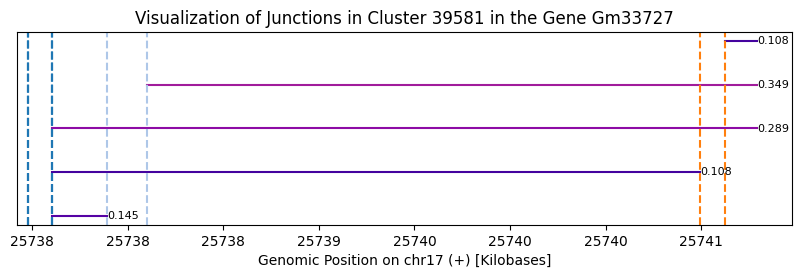

In [10]:
#from LeafletSC.clustering.find_intron_clusters import visualize_junctions
junc_id = dat_vis.junction_id.sample(1).values[0]
j = junc_id
#j = "10_10016372_10027117"
visualize_local_events(dat_vis, j, p_usage_ratio=True)

In [11]:
# extract all the unique gene names in all_juncs_df
gene_names = dat_vis.gene_name.unique()
print(len(gene_names))

5411


In [12]:
# find outliers in all_juncs_df.score using outlier formula anything above 1.5*IQR is an outlier
Q1 = dat_vis.counts_total.quantile(0.25)
Q3 = dat_vis.counts_total.quantile(0.75)
IQR = Q3 - Q1
outliers = dat_vis[(dat_vis.counts_total < (Q1 - 1.5 * IQR)) | (dat_vis.counts_total > (Q3 + 1.5 * IQR))]
print(IQR)

1215.0


In [13]:
outliers.counts_total.min()

3117

In [14]:
print(f"The number of outliers (junction counts_total) in the data is: {len(outliers)}")

The number of outliers (junction counts_total) in the data is: 2097


In [15]:
print(f"The totaln number of junctions in the data is: {len(dat_vis)}")

The totaln number of junctions in the data is: 20858


In [16]:
print(f"Percentage of outliers in the data is: {len(outliers)/len(dat_vis)*100}")

Percentage of outliers in the data is: 10.053696423434653


Text(0, 0.5, 'Number of junctions')

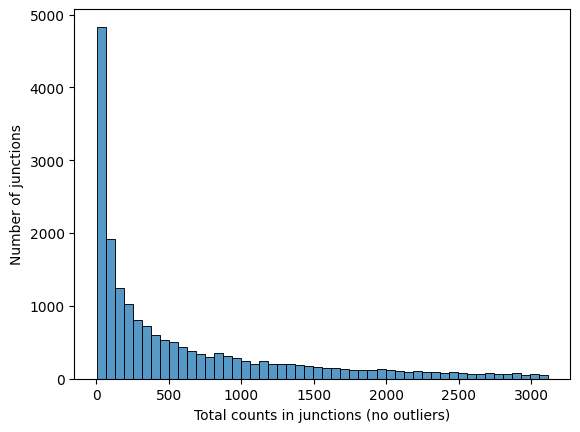

In [17]:
nonoutliers = dat_vis[(dat_vis.counts_total < (Q3 + 1.5 * IQR))]

# xlab is total counts in junctions (non outliers)
# ylab is number of junctions 

xlabel = "Total counts in junctions (no outliers)"
ylabel = "Number of junctions"
sns.histplot(nonoutliers.counts_total)
plt.xlabel(xlabel)
plt.ylabel(ylabel)

In [18]:
# get average number of junctions per cluster here 
avg_juncs_per_cluster = dat_vis.groupby("Cluster").size().mean()
print("The average number of junctions per cluster is: " + str(avg_juncs_per_cluster))

The average number of junctions per cluster is: 2.900166852057842


### Now let's convert the intron clusters to a format that can be used by LeafletSC

In [19]:
intron_clusters = "/gpfs/commons/projects/knowles_singlecell_splicing/CZhang_2018_mouse_dev/male_whole_cortex/LeafletAnalysis/mouse_whole_cortex_dev_leaflet_50_500000_5_20240513_single_cell.gz" # path to the intron clusters file
output_file = output_path + "mouse_whole_cortex_dev_leaflet" # name of the output file
has_genes = "yes" # since we used a gtf file to obtain the intron clusters, we can set this to yes
chunk_size = 5000 # number of junctions to process at a time from the intron clusters files
metadata = None # can replace with path, if metadata is available for cells (cell type, origin, library ID...)

In [20]:
prep_model_input(intron_clusters, output_file, has_genes, chunk_size, metadata)

The intron clusters file you provided is /gpfs/commons/projects/knowles_singlecell_splicing/CZhang_2018_mouse_dev/male_whole_cortex/LeafletAnalysis/mouse_whole_cortex_dev_leaflet_50_500000_5_20240513_single_cell.gz, reading in chunks of 5000 lines
Processing intron clusters


67it [00:03, 17.15it/s]


Done processing intron clusters
The number of intron clusters evaluated is 7192
The number of junctions evaluated is 20858
The number of cells evaluated is 18
The number of clusters with only one junction is 0
A gtf file was used to generate intron clusters
The number of total cells evaluated is 18
The number of cells per cell type is:
cell_type
/gpfs/commons/projects/knowles_singlecell_splicing/CZhang_2018_mouse_dev/male_whole_cortex/Leaflet/SRR1805814_junctions_with_barcodes.bed    1
/gpfs/commons/projects/knowles_singlecell_splicing/CZhang_2018_mouse_dev/male_whole_cortex/Leaflet/SRR1805815_junctions_with_barcodes.bed    1
/gpfs/commons/projects/knowles_singlecell_splicing/CZhang_2018_mouse_dev/male_whole_cortex/Leaflet/SRR1805816_junctions_with_barcodes.bed    1
/gpfs/commons/projects/knowles_singlecell_splicing/CZhang_2018_mouse_dev/male_whole_cortex/Leaflet/SRR1805817_junctions_with_barcodes.bed    1
/gpfs/commons/projects/knowles_singlecell_splicing/CZhang_2018_mouse_dev/male_wh

### Take a quick look at the input file that will go into the model to get familiarized with all the columns

In [21]:
model_input_data = "/gpfs/commons/projects/knowles_singlecell_splicing/CZhang_2018_mouse_dev/male_whole_cortex/LeafletAnalysis/mouse_whole_cortex_dev_leaflet.h5"
summarized_data = pd.read_hdf(model_input_data, 'df')
print(summarized_data.head())

                                             cell_id  Cluster  Cluster_Counts  \
0  SRR1805814_/gpfs/commons/projects/knowles_sing...        3             132   
1  SRR1805814_/gpfs/commons/projects/knowles_sing...        3             132   
2  SRR1805814_/gpfs/commons/projects/knowles_sing...        3             132   
3  SRR1805814_/gpfs/commons/projects/knowles_sing...       19               5   
4  SRR1805814_/gpfs/commons/projects/knowles_sing...       19               5   

             junction_id                gene_id  junc_count  \
0    1_36560920_36563114  ENSMUSG00000001138.14          25   
1    1_36560920_36564246  ENSMUSG00000001138.14          83   
2    1_36563213_36564246  ENSMUSG00000001138.14          24   
3  1_171213306_171213727  ENSMUSG00000006411.13           2   
4  1_171213802_171214148  ENSMUSG00000006411.13           3   

                                           cell_type  junc_ratio  \
0  /gpfs/commons/projects/knowles_singlecell_spli...    0.189394  

In [22]:
# clean up the cell_id column, keep only the first part before "_/"
cell_ids = summarized_data.cell_id.unique()

# clean up the cell_ids values to keep only the first part before "_/"
cell_ids_clean = [c.split("_/")[0] for c in cell_ids]

# make dataframe of old and clean cell_ids and merge wtih summarized_data
cell_ids_df = pd.DataFrame({"cell_id": cell_ids, "cell_id_clean": cell_ids_clean})
summarized_data = summarized_data.merge(cell_ids_df, on="cell_id")

# remove cell_id column and rename cell_id_clean to cell_id column
summarized_data = summarized_data.drop(columns=["cell_id"])
summarized_data = summarized_data.rename(columns={"cell_id_clean": "cell_id"})

In [23]:
summarized_data

,Cluster,Cluster_Counts,junction_id,gene_id,junc_count,cell_type,junc_ratio,cell_id_index,junction_id_index,cell_id
0,3,132,1_36560920_36563114,ENSMUSG00000001138.14,25,/gpfs/commons/projects/knowles_singlecell_spli...,0.189394,0,9356,SRR1805814
1,3,132,1_36560920_36564246,ENSMUSG00000001138.14,83,/gpfs/commons/projects/knowles_singlecell_spli...,0.628788,0,9357,SRR1805814
2,3,132,1_36563213_36564246,ENSMUSG00000001138.14,24,/gpfs/commons/projects/knowles_singlecell_spli...,0.181818,0,9358,SRR1805814
3,19,5,1_171213306_171213727,ENSMUSG00000006411.13,2,/gpfs/commons/projects/knowles_singlecell_spli...,0.400000,0,9078,SRR1805814
4,19,5,1_171213802_171214148,ENSMUSG00000006411.13,3,/gpfs/commons/projects/knowles_singlecell_spli...,0.600000,0,9080,SRR1805814
...,...,...,...,...,...,...,...,...,...,...
332549,44534,362,Y_90804686_90827617,ENSMUSG00000096768.10,265,/gpfs/commons/projects/knowles_singlecell_spli...,0.732044,17,20856,SRR1812034
332550,44534,362,Y_90804949_90827617,ENSMUSG00000096768.10,97,/gpfs/commons/projects/knowles_singlecell_spli...,0.267956,17,20857,SRR1812034
332551,44541,71,Y_1168185_1169122,ENSMUSG00000068457.15,27,/gpfs/commons/projects/knowles_singlecell_spli...,0.380282,17,20853,SRR1812034
332552,44541,71,Y_1168185_1169964,ENSMUSG00000068457.15,19,/gpfs/commons/projects/knowles_singlecell_spli...,0.267606,17,20854,SRR1812034


In [24]:
# now let's see how many junctions are detected in a single cell 
junctions_per_cell = summarized_data.groupby("cell_id").size()
total_num_juncs = summarized_data.junction_id.nunique()

# get percentage of junctions detected in a single cell
percentage_juncs_per_cell = junctions_per_cell/total_num_juncs * 100
percentage_juncs_per_cell = percentage_juncs_per_cell.reset_index()
percentage_juncs_per_cell.columns = ["cell_id", "percentage_junctions"]

# add also the number of junctions detected in a single cell
junctions_per_cell = junctions_per_cell.reset_index()
junctions_per_cell.columns = ["cell_id", "num_junctions"]

# get also number of unique gene_ids detected in a single cell 
unique_genes_per_cell = summarized_data.groupby("cell_id").gene_id.nunique()
unique_genes_per_cell = unique_genes_per_cell.reset_index()
unique_genes_per_cell.columns = ["cell_id", "num_genes"]

# get also number of unique Cluster detected in a single cell
unique_clusters_per_cell = summarized_data.groupby("cell_id").Cluster.nunique()
unique_clusters_per_cell = unique_clusters_per_cell.reset_index()
unique_clusters_per_cell.columns = ["cell_id", "num_clusters"]

# num of cells a junction is detected in 
cells_per_junc = summarized_data.groupby("junction_id").size()
cells_per_junc = cells_per_junc.reset_index()
cells_per_junc.columns = ["junction_id", "num_cells"]
cells_per_junc

,junction_id,num_cells
0,10_10016372_10027117,11
1,10_102186845_102206193,18
2,10_102186845_102214012,15
3,10_102206254_102214012,18
4,10_103057320_103059553,17
...,...,...
20853,Y_1168185_1169122,18
20854,Y_1168185_1169964,18
20855,Y_1169257_1169964,18
20856,Y_90804686_90827617,18


In [25]:
cells_per_junc.num_cells.min()

2

Text(0, 0.5, '# of junctions')

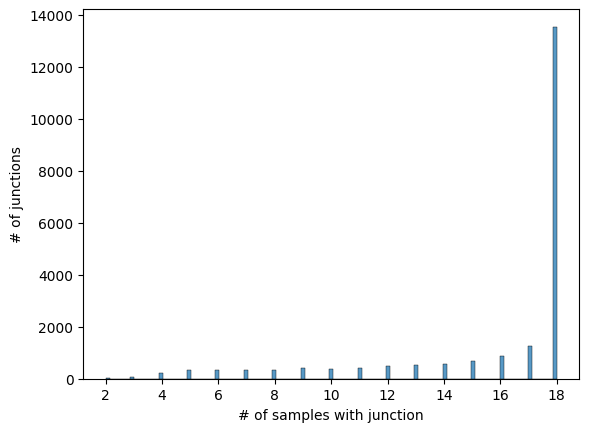

In [26]:
# make a histogram 
sns.histplot(cells_per_junc.num_cells)
xlab="# of samples with junction"
ylab="# of junctions"
plt.xlabel(xlab)
plt.ylabel(ylab)

Text(0, 0.5, '# of samples')

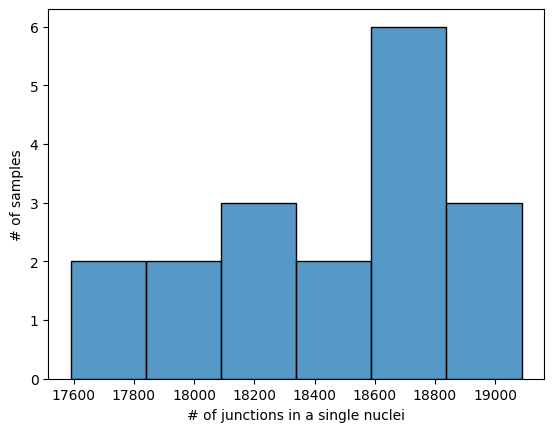

In [27]:
# make a histogram 
sns.histplot(junctions_per_cell.num_junctions)
xlab="# of junctions in a single nuclei"
ylab="# of samples"
plt.xlabel(xlab)
plt.ylabel(ylab)

Text(0, 0.5, '# of samples')

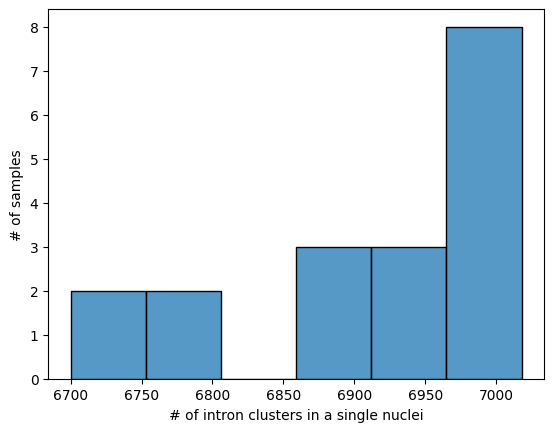

In [28]:
# make a histogram 
sns.histplot(unique_clusters_per_cell.num_clusters)
xlab="# of intron clusters in a single nuclei"
ylab="# of samples"
plt.xlabel(xlab)
plt.ylabel(ylab)

Text(0, 0.5, '# of samples')

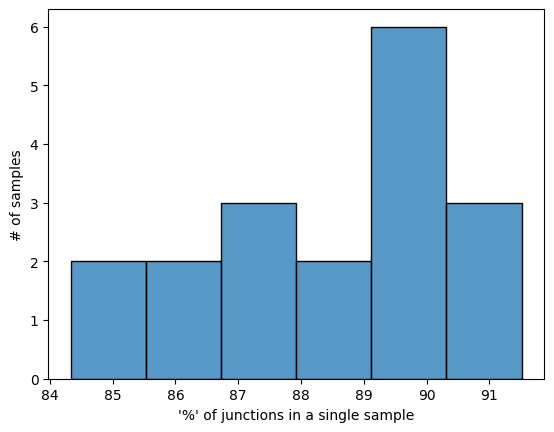

In [29]:
# make a histogram 
sns.histplot(percentage_juncs_per_cell.percentage_junctions)
xlab="'%' of junctions in a single sample"
ylab="# of samples"
plt.xlabel(xlab)
plt.ylabel(ylab)

Text(0, 0.5, '# of nuclei')

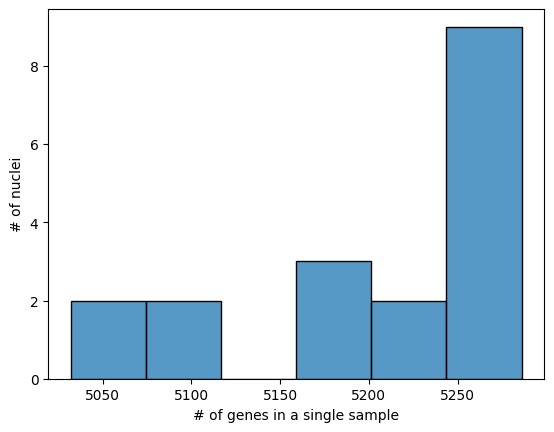

In [30]:
# make a histogram 
sns.histplot(unique_genes_per_cell.num_genes)
xlab="# of genes in a single sample"
ylab="# of nuclei"
plt.xlabel(xlab)
plt.ylabel(ylab)

<Axes: xlabel='junc_ratio', ylabel='Count'>

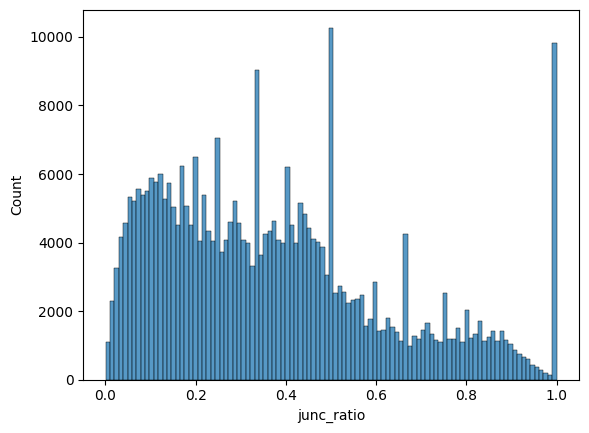

In [31]:
# make a histogram of junction ratios
sns.histplot(summarized_data.junc_ratio)

In [32]:
summarized_data.head()

,Cluster,Cluster_Counts,junction_id,gene_id,junc_count,cell_type,junc_ratio,cell_id_index,junction_id_index,cell_id
0,3,132,1_36560920_36563114,ENSMUSG00000001138.14,25,/gpfs/commons/projects/knowles_singlecell_spli...,0.189394,0,9356,SRR1805814
1,3,132,1_36560920_36564246,ENSMUSG00000001138.14,83,/gpfs/commons/projects/knowles_singlecell_spli...,0.628788,0,9357,SRR1805814
2,3,132,1_36563213_36564246,ENSMUSG00000001138.14,24,/gpfs/commons/projects/knowles_singlecell_spli...,0.181818,0,9358,SRR1805814
3,19,5,1_171213306_171213727,ENSMUSG00000006411.13,2,/gpfs/commons/projects/knowles_singlecell_spli...,0.400000,0,9078,SRR1805814
4,19,5,1_171213802_171214148,ENSMUSG00000006411.13,3,/gpfs/commons/projects/knowles_singlecell_spli...,0.600000,0,9080,SRR1805814


In [33]:
cells_pub.iloc[0]

Run                                             SRR1805814
AGE                                                  E14.5
Assay Type                                         RNA-Seq
AvgSpotLen                                             202
Bases                                          10884925944
BioProject                                     PRJNA275412
BioSample                                     SAMN03344261
BioSampleModel                    Model organism or animal
Bytes                                           7350069982
Center Name             COLUMBIA UNIVERSITY MEDICAL CENTER
Consent                                             public
DATASTORE filetype                        fastq,run.zq,sra
DATASTORE provider                              gs,ncbi,s3
DATASTORE region      gs.us-east1,ncbi.public,s3.us-east-1
Experiment                                       SRX878740
Instrument                             Illumina HiSeq 2000
Library Name                                           N

In [34]:
cells_pub["cell_id"] = cells_pub["Run"]
cells_pub["cell_type"] = cells_pub["AGE"]
cells_info = cells_pub[["cell_id", "cell_type"]]

In [35]:
# remove cell type column from summarized_data 
summarized_data = summarized_data.drop(columns=["cell_type"])

In [36]:
cells_info.cell_type.value_counts()

cell_type
E14.5    2
E16.5    2
P0a      1
P0b      1
P4a      1
P4b      1
21Mb     1
21Ma     1
P110b    1
P110a    1
P30a     1
P30b     1
P15b     1
P15a     1
P7b      1
P7a      1
Name: count, dtype: int64

In [37]:
# remove "a" and "b" from cell_type when present 
cells_info.cell_type = cells_info.cell_type.str.replace("a", "")
cells_info.cell_type = cells_info.cell_type.str.replace("b", "")
cells_info

/scratch/ipykernel_29258/812136228.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cells_info.cell_type = cells_info.cell_type.str.replace("a", "")
/scratch/ipykernel_29258/812136228.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cells_info.cell_type = cells_info.cell_type.str.replace("b", "")


,cell_id,cell_type
0,SRR1805814,E14.5
1,SRR1805815,E14.5
2,SRR1805816,P0
3,SRR1805817,P0
4,SRR1805818,P4
5,SRR1805819,P4
6,SRR1805820,21M
7,SRR1805821,21M
8,SRR1805822,P110
9,SRR1805823,P110


In [38]:
# now merge with cells_pub on cell_id
summarized_data = summarized_data.merge(cells_info, on="cell_id")

In [39]:
summarized_data.to_hdf(model_input_data, key='df', mode='w', complevel=9, complib='zlib', format="table")  

In [40]:
model_input_data

'/gpfs/commons/projects/knowles_singlecell_splicing/CZhang_2018_mouse_dev/male_whole_cortex/LeafletAnalysis/mouse_whole_cortex_dev_leaflet.h5'

In [41]:
summarized_data

,Cluster,Cluster_Counts,junction_id,gene_id,junc_count,junc_ratio,cell_id_index,junction_id_index,cell_id,cell_type
0,3,132,1_36560920_36563114,ENSMUSG00000001138.14,25,0.189394,0,9356,SRR1805814,E14.5
1,3,132,1_36560920_36564246,ENSMUSG00000001138.14,83,0.628788,0,9357,SRR1805814,E14.5
2,3,132,1_36563213_36564246,ENSMUSG00000001138.14,24,0.181818,0,9358,SRR1805814,E14.5
3,19,5,1_171213306_171213727,ENSMUSG00000006411.13,2,0.400000,0,9078,SRR1805814,E14.5
4,19,5,1_171213802_171214148,ENSMUSG00000006411.13,3,0.600000,0,9080,SRR1805814,E14.5
...,...,...,...,...,...,...,...,...,...,...
332549,44534,362,Y_90804686_90827617,ENSMUSG00000096768.10,265,0.732044,17,20856,SRR1812034,E16.5
332550,44534,362,Y_90804949_90827617,ENSMUSG00000096768.10,97,0.267956,17,20857,SRR1812034,E16.5
332551,44541,71,Y_1168185_1169122,ENSMUSG00000068457.15,27,0.380282,17,20853,SRR1812034,E16.5
332552,44541,71,Y_1168185_1169964,ENSMUSG00000068457.15,19,0.267606,17,20854,SRR1812034,E16.5


In [42]:
summarized_data.cell_type.value_counts()

cell_type
P7       37893
21M      37469
P110     37439
P15      37373
P0       37323
P4       37218
P30      36577
E16.5    35999
E14.5    35263
Name: count, dtype: int64